In [49]:
#imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## Processed Dataset(from Q1)

In [50]:
# Load the dataset
df = pd.read_csv('TaxiData.csv')

# Convert trip_start_timestamp to datetime
df['trip_start_timestamp'] = pd.to_datetime(df['trip_start_timestamp'], unit='s')

# Ensure community areas are categorical
df['pickup_community_area'] = df['pickup_community_area'].astype('category')
df['dropoff_community_area'] = df['dropoff_community_area'].astype('category')

import warnings
warnings.filterwarnings("ignore")
# Impute numerical columns with mean
numerical_cols = ['fare', 'trip_miles', 'trip_seconds', 'tips']
for col in numerical_cols:
    df[col].fillna(df[col].mean(), inplace=True)

# Impute categorical columns with mode or label as 'Unknown'
categorical_cols = ['payment_type', 'company']
for col in categorical_cols:
    df[col].fillna('Unknown', inplace=True)

# Drop rows with missing latitude/longitude data if they are critical
df.dropna(subset=['pickup_latitude', 'pickup_longitude', 'dropoff_latitude', 'dropoff_longitude'], inplace=True)

## 2.a Trip Frequency by Time of Day, Month, and Day

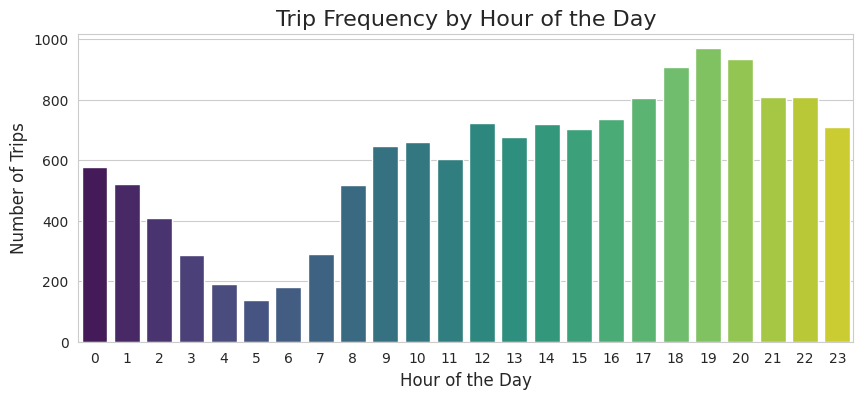

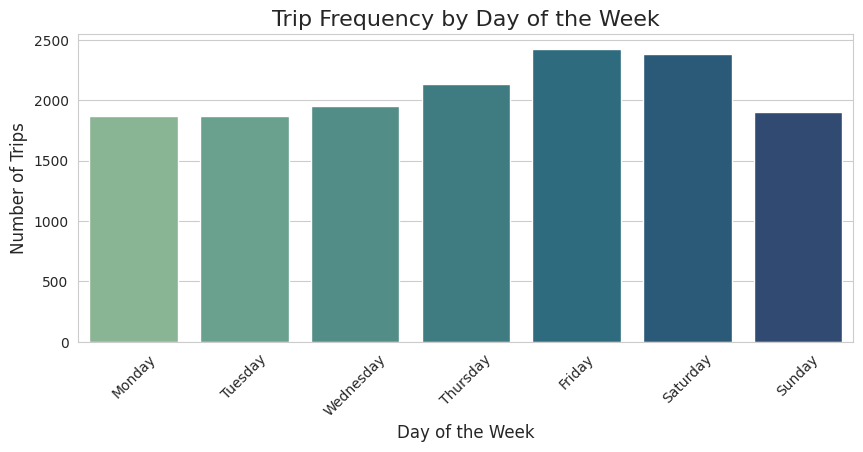

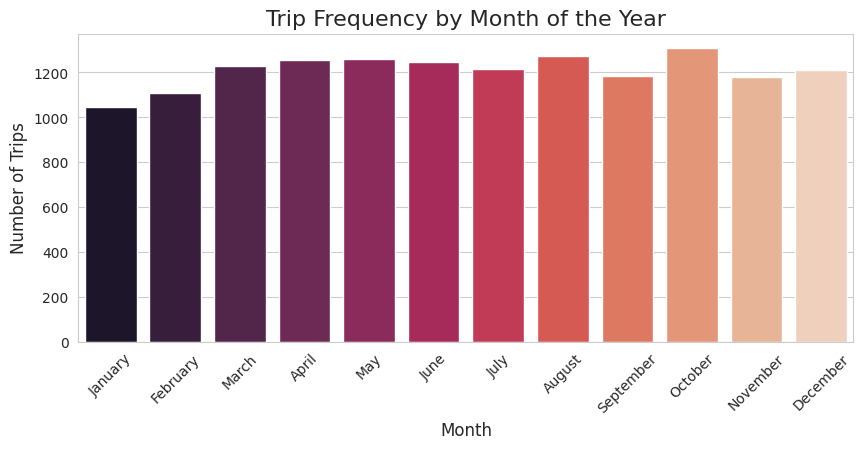

In [64]:

# Extract time-related features if not already in the dataset
df['trip_start_hour'] = df['trip_start_timestamp'].dt.hour
df['trip_start_day'] = df['trip_start_timestamp'].dt.day_name()
df['trip_start_month'] = df['trip_start_timestamp'].dt.month_name()

# Set plot style for better aesthetics
sns.set_style("whitegrid")

# 1. Trip frequency by hour of the day
plt.figure(figsize=(10,4))
sns.countplot(x='trip_start_hour', data=df, palette='viridis')
plt.title('Trip Frequency by Hour of the Day', fontsize=16)
plt.xlabel('Hour of the Day', fontsize=12)
plt.ylabel('Number of Trips', fontsize=12)
plt.show()

# 2. Trip frequency by day of the week
plt.figure(figsize=(10,4))
sns.countplot(x='trip_start_day', data=df, order=['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday'], palette='crest')
plt.title('Trip Frequency by Day of the Week', fontsize=16)
plt.xlabel('Day of the Week', fontsize=12)
plt.ylabel('Number of Trips', fontsize=12)
plt.xticks(rotation=45)
plt.show()

# 3. Trip frequency by month of the year
plt.figure(figsize=(10,4))
sns.countplot(x='trip_start_month', data=df, order=['January', 'February', 'March', 'April', 'May', 'June', 'July', 'August', 'September', 'October', 'November', 'December'], palette='rocket')
plt.title('Trip Frequency by Month of the Year', fontsize=16)
plt.xlabel('Month', fontsize=12)
plt.ylabel('Number of Trips', fontsize=12)
plt.xticks(rotation=45)
plt.show()


```
Analysis:

Peak Hours:
The bar chart for hours of the day will help identify peak hours (e.g., morning rush hour around 8-10 AM and evening rush hour around 6-9 PM). This pattern highlights when the most rides occur, indicating high-demand times.

High-Demand Days:
The day of the week chart can reveal if there are significant differences between weekdays and weekends. Typically, weekdays may show consistent demand due to work commutes, while weekends may have more varied patterns based on leisure activities. However Friday and saturday have maximum number of trips.

Seasonal Trends:
The month chart can show seasonal variations, such as higher trips during summer months or holidays, suggesting seasonally high demand. This trend can be vital for resource allocation during peak months. In the plot above October shows maximum counts.

Relevance for Managing Taxi Demand
Identifying peak hours helps in optimizing the number of taxis available during those times, ensuring sufficient supply to meet demand and understanding demand on specific days and times enables better scheduling of drivers to maximize earnings and minimize idle time.
```

## 2.b Peak Hours and Distance Analysis

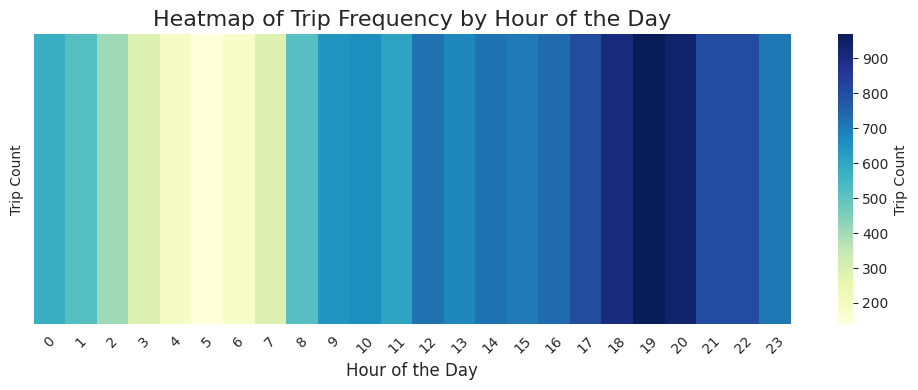

In [52]:
# Create a heatmap for trip frequency by hour of the day
plt.figure(figsize=(10,4))
hourly_counts = df['trip_start_hour'].value_counts().sort_index()

# Convert hourly counts to a DataFrame
hourly_counts_df = pd.DataFrame(hourly_counts).reset_index()
hourly_counts_df.columns = ['Hour', 'Trip Count']

# Plot heatmap without annotations for clarity
sns.heatmap(hourly_counts_df.set_index('Hour').T, cmap='YlGnBu', annot=False, cbar_kws={'label': 'Trip Count'})
plt.title('Heatmap of Trip Frequency by Hour of the Day', fontsize=16)
plt.xlabel('Hour of the Day', fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Clearly the maximum counts occurs during 18-20 hours of the day

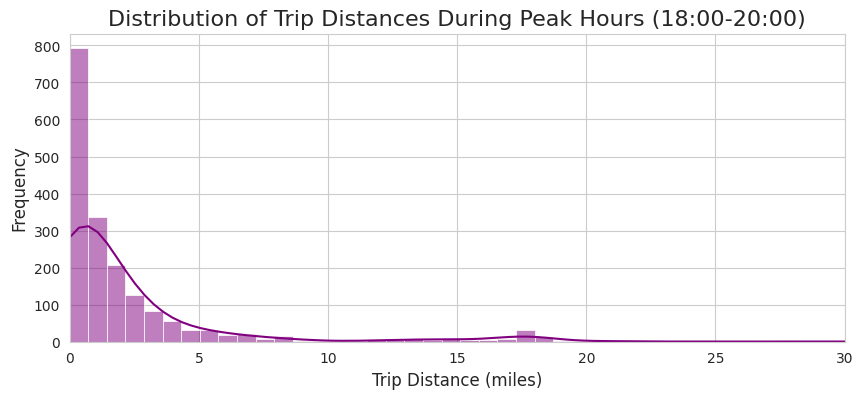

In [53]:
# Assuming peak hours are from 17:00 to 19:00 based on the heatmap
peak_hours = [18, 20]  # Adjust as per your data analysis

# Filter data for peak hours
peak_hour_data = df[df['trip_start_hour'].isin(peak_hours)]

# Plot histogram of trip distances during peak hours
plt.figure(figsize=(10,4))
sns.histplot(peak_hour_data['trip_miles'], bins=100, kde=True, color='purple')
plt.xlim(0, 30)
plt.title('Distribution of Trip Distances During Peak Hours (18:00-20:00)', fontsize=16)
plt.xlabel('Trip Distance (miles)', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.show()

```
Implications:

Congestion: High demand during peak hours may lead to congestion, reducing the average speed of travel.
Wait Times: Longer trips during peak hours could reduce taxi availability, increasing wait times for other customers.
Efficiency: Knowing if peak hour trips are short or long can help optimize driver deployment, balancing between short rides and potentially higher fares from longer trips.
```

## 2.c Trip Duration and Distance Distribution

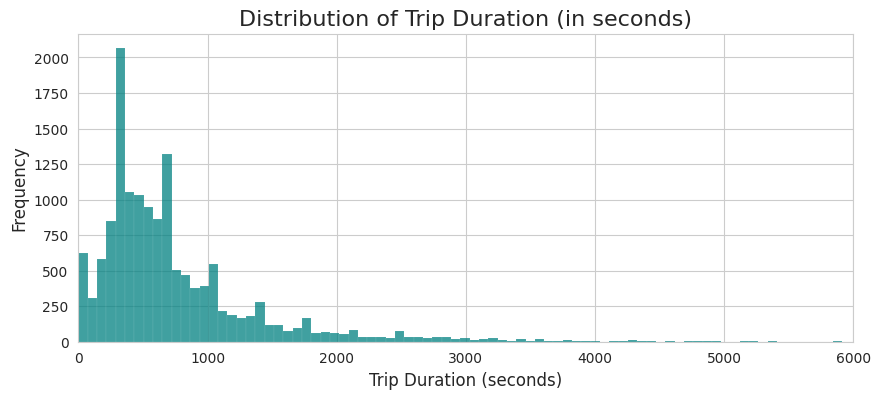

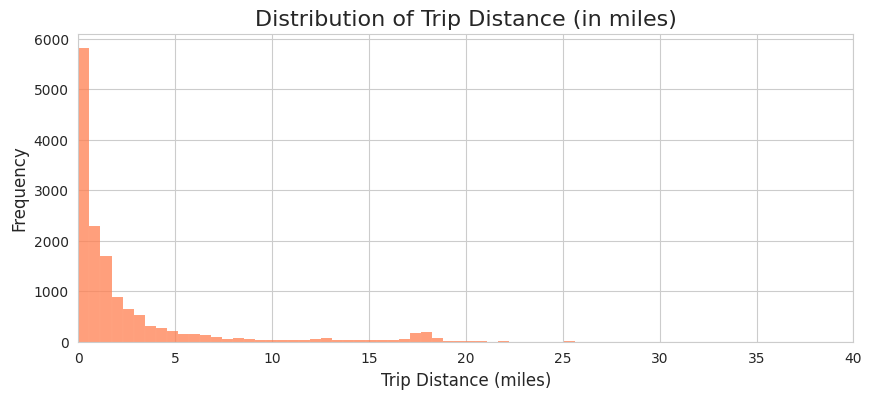

In [54]:
# Plot histogram for trip duration (trip_seconds)
plt.figure(figsize=(10,4))
sns.histplot(df['trip_seconds'], bins=1000, kde=False, color='teal')
plt.title('Distribution of Trip Duration (in seconds)', fontsize=16)
plt.xlim(0, 6000)
plt.xlabel('Trip Duration (seconds)', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.show()

# Plot histogram for trip distance (trip_miles)
plt.figure(figsize=(10,4))
sns.histplot(df['trip_miles'], bins=3000, kde=False, color='coral')
plt.xlim(0, 40)
plt.title('Distribution of Trip Distance (in miles)', fontsize=16)
plt.xlabel('Trip Distance (miles)', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.show()

```
Analysis:

1.) For trip duration distribution
The histogram shows that the majority of trips have a duration clustered at the lower end, with most trips lasting significantly less than 10,000 seconds (~2.8 hours). This suggests that most taxi rides are relatively short.

2.) For trip distance distribution
 Most trips are concentrated at very short distances, with a significant drop-off as distance increases. The histogram's long right tail indicates that while most trips are short (likely under 10 miles), there are some outliers with extremely high values.
```

Correlation Analysis with a Scatter Plot

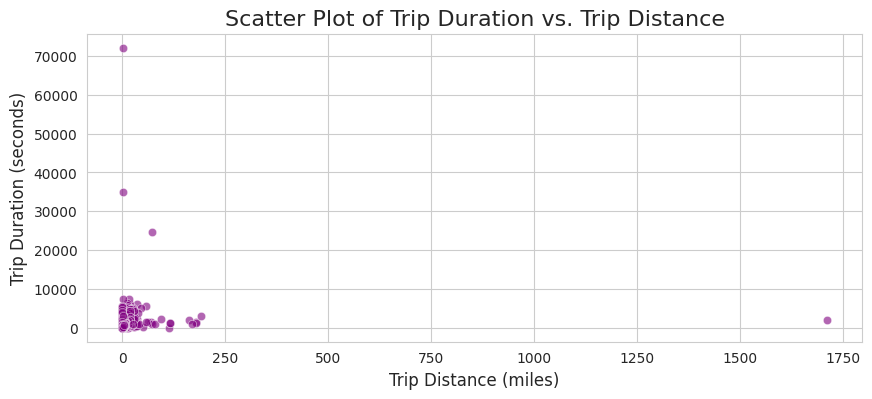

In [55]:
# Scatter plot for trip duration vs. trip distance
plt.figure(figsize=(10,4))
sns.scatterplot(x='trip_miles', y='trip_seconds', data=df, alpha=0.6, color='purple')
plt.title('Scatter Plot of Trip Duration vs. Trip Distance', fontsize=16)
plt.xlabel('Trip Distance (miles)', fontsize=12)
plt.ylabel('Trip Duration (seconds)', fontsize=12)
plt.show()

```
The scatter plot of Trip Duration (in seconds) versus Trip Distance (in miles) shows a dense cluster of points near the origin, with most trips having shorter distances and durations. However, there are some clear outliers:

1.)Long Duration, Short Distance: There is a point around 70,000 seconds with a very low trip distance, suggesting that some trips took an unusually long time despite covering minimal distance. This could indicate delays, traffic issues, or non-moving periods (like waiting time).

2.)Long Distance, Low Duration: Another outlier appears around 1,750 miles with a relatively short trip duration. This could represent an error in data entry or represent a high-speed trip, which seems unusual given the extreme distance.
```

## 2.d Seasonal Trends in Taxi Usage and Distance 

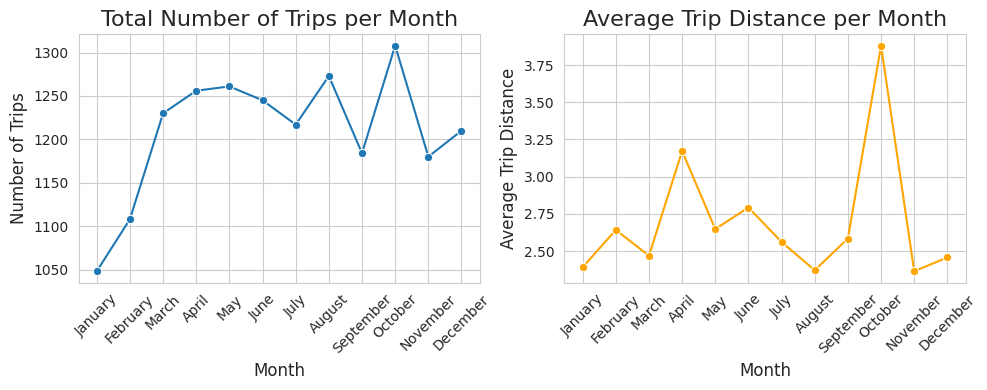

In [56]:
# Calculate the total number of trips and average distance per month
monthly_data = df.groupby('trip_start_month').agg(total_trips=('trip_start_timestamp', 'count'),average_distance=('trip_miles', 'mean')).reindex(
    ['January', 'February', 'March', 'April', 'May', 'June', 'July', 'August', 'September', 'October', 'November', 'December']).reset_index()

# Plotting
plt.figure(figsize=(10,4))

# Plot 1: Number of Trips per Month
plt.subplot(1, 2, 1)
sns.lineplot(data=monthly_data, x='trip_start_month', y='total_trips', marker='o')
plt.title('Total Number of Trips per Month', fontsize=16)
plt.xlabel('Month', fontsize=12)
plt.ylabel('Number of Trips', fontsize=12)
plt.xticks(rotation=45)

# Plot 2: Average Trip Distance per Month
plt.subplot(1, 2, 2)
sns.lineplot(data=monthly_data, x='trip_start_month', y='average_distance', marker='o', color='orange')
plt.title('Average Trip Distance per Month', fontsize=16)
plt.xlabel('Month', fontsize=12)
plt.ylabel('Average Trip Distance', fontsize=12)
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

```
Analysis:

1.) October stands out as a high-demand period with both an increased number of trips and longer trip distances. To prepare for October, allocate additional resources for increased coverage, fuel, and maintenance support.

2.) For other peak months (July and February), adjust resource allocation based on trip numbers rather than distance, focusing on high-demand areas.

3.) January and December might allow for a reduction in resources due to lower demand, enabling cost savings without significantly impacting service.
```

## 2.e Distance vs. Time of Day

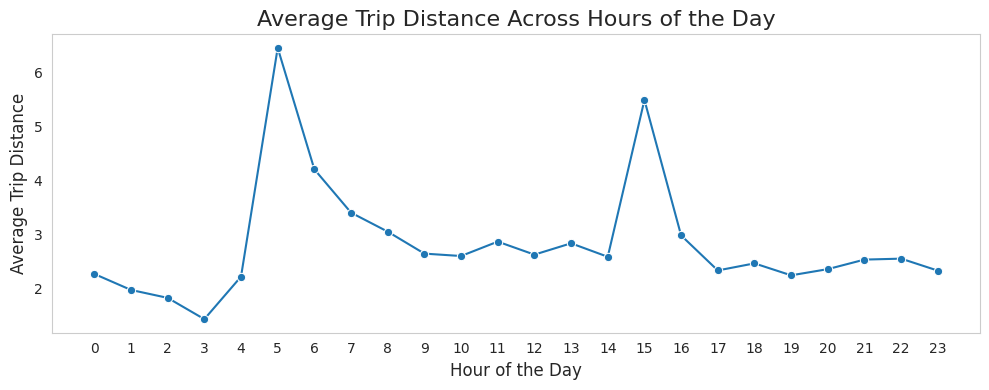

In [58]:
# Calculate average trip distance for each hour
avg_distance_per_hour = df.groupby('trip_start_hour')['trip_miles'].mean().reset_index()

# Plotting
plt.figure(figsize=(10,4))
sns.lineplot(data=avg_distance_per_hour, x='trip_start_hour', y='trip_miles', marker='o')
plt.title('Average Trip Distance Across Hours of the Day', fontsize=16)
plt.xlabel('Hour of the Day', fontsize=12)
plt.ylabel('Average Trip Distance', fontsize=12)
plt.xticks(range(24))  # Show all hours
plt.grid()

plt.tight_layout()
plt.show()

```
Analysis:

1.) Peak Hours (5 AM and 3 PM): Longer distances indicate that focusing on strategic areas, such as transportation hubs, can help address specific travel needs during these times.

2.) Non-Peak Hours: Shorter, localized trips during most daytime and nighttime hours suggest resources should be concentrated in urban areas to meet the demand for quick, local travel.

3.) Late Night: Lower demand and shorter distances during this time allow for a reduced resource allocation.

These findings suggest adjusting resource deployment based on typical trip distances at different hours, ensuring efficient service during high-demand periods and cost savings during low-demand periods.
```